In [1]:
# ==========================================================
# IMPORT LIBRARIES
# ==========================================================

import os
import cv2
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report

from tensorflow.keras.utils import Sequence

from tensorflow.keras.applications import EfficientNetV2B0

from tensorflow.keras.layers import (
    Dense,
    Dropout,
    GlobalAveragePooling2D
)

from tensorflow.keras.models import Model

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

from tensorflow.keras.optimizers import Adam

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [2]:
# ==========================================================
# LOAD CSV FILES
# ==========================================================

train_df = pd.read_csv("D:\multidieseases\Training_Set\Training_Set\RFMiD_Training_Labels.csv")

val_df = pd.read_csv("D:\multidieseases\Evaluation_Set\Evaluation_Set\RFMiD_Validation_Labels.csv")

test_df = pd.read_csv("D:\multidieseases\Test_Set\Test_Set\RFMiD_Testing_Labels.csv")

print("Training Shape :", train_df.shape)
print("Validation Shape :", val_df.shape)
print("Testing Shape :", test_df.shape)

Training Shape : (1920, 47)
Validation Shape : (640, 47)
Testing Shape : (640, 47)


In [3]:
# ==========================================================
# SELECT DISEASES
# ==========================================================

selected_diseases = [

    "DR",
    "ARMD",
    "MH",
    "DN",
    "MYA",
    "BRVO",
    "TSLN",
    "LS",
    "CSR",
    "ODC",
    "ODP",
    "ODE",
    "RS",
    "CRS"

]

print("Total Diseases:", len(selected_diseases))

Total Diseases: 14


In [5]:
# ==========================================================
# DATASET PATHS
# ==========================================================

# Training images
train_img_dir = r"D:\multidieseases\Training_Set\Training_Set\Training"

# Validation images
val_img_dir = r"D:\multidieseases\Evaluation_Set\Evaluation_Set\Validation"

# Test images
test_img_dir = r"D:\multidieseases\Test_Set\Test_Set\Test"


# CSV files
train_csv = r"D:\multidieseases\Training_Set\Training_Set\RFMiD_Training_Labels.csv"

val_csv = r"D:\multidieseases\Evaluation_Set\Evaluation_Set\RFMiD_Validation_Labels.csv"

test_csv = r"D:\multidieseases\Test_Set\Test_Set\RFMiD_Testing_Labels.csv"

In [6]:
# ==========================================================
# PREPARE DATAFRAME
# ==========================================================

def prepare_dataframe(df, image_folder):

    data = df.copy()

    # Create image filename
    data["filename"] = data["ID"].astype(str) + ".png"

    # Create full image path
    data["image_path"] = data["filename"].apply(
        lambda x: os.path.join(image_folder, x)
    )

    # Keep only required columns
    columns = ["image_path"] + selected_diseases

    return data[columns]


train_data = prepare_dataframe(train_df, train_img_dir)

val_data = prepare_dataframe(val_df, val_img_dir)

test_data = prepare_dataframe(test_df, test_img_dir)

print(train_data.head())

                                          image_path  DR  ARMD  MH  DN  MYA  \
0  D:\multidieseases\Training_Set\Training_Set\Tr...   1     0   0   0    0   
1  D:\multidieseases\Training_Set\Training_Set\Tr...   1     0   0   0    0   
2  D:\multidieseases\Training_Set\Training_Set\Tr...   1     0   0   0    0   
3  D:\multidieseases\Training_Set\Training_Set\Tr...   0     0   1   0    0   
4  D:\multidieseases\Training_Set\Training_Set\Tr...   1     0   0   0    0   

   BRVO  TSLN  LS  CSR  ODC  ODP  ODE  RS  CRS  
0     0     0   0    0    0    0    0   0    0  
1     0     0   0    0    0    0    0   0    0  
2     0     0   0    0    0    0    0   0    0  
3     0     0   0    0    1    0    0   0    0  
4     0     0   1    0    0    0    0   0    0  


In [7]:
# ==========================================================
# CHECK FOR MISSING IMAGES
# ==========================================================

def check_missing(df, name):

    missing = df[~df["image_path"].apply(os.path.exists)]

    print(f"{name} Missing Images: {len(missing)}")

    if len(missing) > 0:
        print(missing.head())

check_missing(train_data, "Train")
check_missing(val_data, "Validation")
check_missing(test_data, "Test")

Train Missing Images: 0
Validation Missing Images: 0
Test Missing Images: 0


In [11]:
# ==========================================================
# CUSTOM MULTI-LABEL DATA GENERATOR
# ==========================================================

class RFMIDGenerator(Sequence):

    def __init__(
        self,
        dataframe,
        batch_size=32,
        image_size=(224,224),
        shuffle=True,
        augment=False
    ):

        self.df = dataframe.reset_index(drop=True)
        self.batch_size = batch_size
        self.image_size = image_size
        self.shuffle = shuffle
        self.augment = augment

        self.indices = np.arange(len(self.df))

        self.on_epoch_end()

    def __len__(self):

        return int(np.ceil(len(self.df) / self.batch_size))

    def on_epoch_end(self):

        if self.shuffle:
            np.random.shuffle(self.indices)

    def __getitem__(self, index):

        batch_indices = self.indices[
            index*self.batch_size:(index+1)*self.batch_size
        ]

        batch_df = self.df.iloc[batch_indices]

        images = []
        labels = []

        for _, row in batch_df.iterrows():

            img = cv2.imread(row["image_path"])

            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            img = cv2.resize(img, self.image_size)

            img = img.astype(np.float32)

            # --------------------------------------------------
            # DATA AUGMENTATION
            # --------------------------------------------------

            if self.augment:

                if np.random.rand() < 0.3:

                    angle = np.random.uniform(-15,15)

                    M = cv2.getRotationMatrix2D(
                        (112,112),
                        angle,
                        1
                    )

                    img = cv2.warpAffine(
                        img,
                        M,
                        (224,224)
                    )

            images.append(img)

            labels.append(
                row[selected_diseases].values.astype(np.float32)
            )

        X = np.array(images)

        y = np.array(labels)

        return X, y

In [9]:
# ==========================================================
# CREATE DATA GENERATORS
# ==========================================================

train_generator = RFMIDGenerator(
    train_data,
    batch_size=32,
    image_size=(224,224),
    shuffle=True,
    augment=True
)

val_generator = RFMIDGenerator(
    val_data,
    batch_size=32,
    image_size=(224,224),
    shuffle=False,
    augment=False
)

test_generator = RFMIDGenerator(
    test_data,
    batch_size=32,
    image_size=(224,224),
    shuffle=False,
    augment=False
)

In [10]:
# ==========================================================
# CHECK GENERATOR
# ==========================================================

X, y = train_generator[0]

print("Images :", X.shape)

print("Labels :", y.shape)

print("First Label:")

print(y[0])

Images : (32, 224, 224, 3)
Labels : (32, 14)
First Label:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [12]:
# ==========================================================
# CLASS DISTRIBUTION
# ==========================================================

label_matrix = train_data[selected_diseases].values

positive_counts = label_matrix.sum(axis=0)

negative_counts = len(label_matrix) - positive_counts

for disease, pos in zip(selected_diseases, positive_counts):
    print(f"{disease:6s}: {int(pos)}")

DR    : 376
ARMD  : 100
MH    : 317
DN    : 138
MYA   : 101
BRVO  : 73
TSLN  : 186
LS    : 47
CSR   : 37
ODC   : 282
ODP   : 65
ODE   : 58
RS    : 43
CRS   : 32


In [17]:
# ==========================================================
# DISEASE DISTRIBUTION
# ==========================================================

print(train_data[selected_diseases].sum())

DR      376
ARMD    100
MH      317
DN      138
MYA     101
BRVO     73
TSLN    186
LS       47
CSR      37
ODC     282
ODP      65
ODE      58
RS       43
CRS      32
dtype: int64


In [13]:
# ==========================================================
# BUILD MODEL
# ==========================================================

base_model = EfficientNetV2B0(
    include_top=False,
    weights="imagenet",
    input_shape=(224,224,3)
)

base_model.trainable = False

x = GlobalAveragePooling2D()(base_model.output)

x = Dense(256, activation="relu")(x)

x = Dropout(0.4)(x)

outputs = Dense(
    len(selected_diseases),
    activation="sigmoid"
)(x)

model = Model(
    inputs=base_model.input,
    outputs=outputs
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          0 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ normalization[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │      4,608 │ stem_activation[… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_bn  │ (None, 112, 112,  │         64 │ block1a_project_… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_ac… │ (None, 112, 112,  │          0 │ block1a_project_… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_conv │ (None, 56, 56,    │      9,216 │ block1a_project_… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_bn   │ (None, 56, 56,    │        256 │ block2a_expand_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_act… │ (None, 56, 56,    │          0 │ block2a_expand_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_co… │ (None, 56, 56,    │      2,048 │ block2a_expand_a… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_bn  │ (None, 56, 56,    │        128 │ block2a_project_… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_conv │ (None, 56, 56,    │     36,864 │ block2a_project_… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_bn   │ (None, 56, 56,    │        512 │ block2b_expand_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_act… │ (None, 56, 56,    │          0 │ block2b_expand_b

 Total params: 6,250,846 (23.85 MB)

 Trainable params: 331,534 (1.26 MB)

 Non-trainable params: 5,919,312 (22.58 MB)

In [ ]:
# ==========================================================
# COMPILE MODEL
# ==========================================================

model.compile(

    optimizer=Adam(learning_rate=1e-4),

    loss="binary_crossentropy",

    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.AUC(name="auc")
    ]

)

In [15]:
# ==========================================================
# CALLBACKS
# ==========================================================

early_stop = EarlyStopping(

    monitor="val_loss",

    patience=5,

    restore_best_weights=True

)

reduce_lr = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.2,

    patience=2,

    min_lr=1e-6

)

In [16]:
# ==========================================================
# INITIAL TRAINING
# ==========================================================

history = model.fit(

    train_generator,

    validation_data=val_generator,

    epochs=15,

    callbacks=[early_stop, reduce_lr]

)

C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.7185 - auc: 0.4610 - loss: 0.5575

C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


60/60 ━━━━━━━━━━━━━━━━━━━━ 812s 13s/step - accuracy: 0.8461 - auc: 0.5425 - loss: 0.4085 - val_accuracy: 0.9317 - val_auc: 0.7238 - val_loss: 0.2299 - learning_rate: 1.0000e-04
Epoch 2/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 468s 8s/step - accuracy: 0.9306 - auc: 0.6749 - loss: 0.2458 - val_accuracy: 0.9327 - val_auc: 0.7709 - val_loss: 0.2099 - learning_rate: 1.0000e-04
Epoch 3/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 430s 7s/step - accuracy: 0.9323 - auc: 0.7279 - loss: 0.2280 - val_accuracy: 0.9350 - val_auc: 0.8007 - val_loss: 0.2001 - learning_rate: 1.0000e-04
Epoch 4/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 423s 7s/step - accuracy: 0.9347 - auc: 0.7508 - loss: 0.2183 - val_accuracy: 0.9377 - val_auc: 0.8152 - val_loss: 0.1939 - learning_rate: 1.0000e-04
Epoch 5/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 396s 7s/step - accuracy: 0.9366 - auc: 0.7753 - loss: 0.2109 - val_accuracy: 0.9392 - val_auc: 0.8311 - val_loss: 0.1889 - learning_rate: 1.0000e-04
Epoch 6/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 458s 8s/step - accuracy: 0.9372 - auc

In [18]:
# ==========================================================
# CLASS DISTRIBUTION
# ==========================================================

label_matrix = train_data[selected_diseases].values

positive_counts = label_matrix.sum(axis=0)

negative_counts = len(label_matrix) - positive_counts

for disease, pos in zip(selected_diseases, positive_counts):
    print(f"{disease:6s}: {int(pos)}")

DR    : 376
ARMD  : 100
MH    : 317
DN    : 138
MYA   : 101
BRVO  : 73
TSLN  : 186
LS    : 47
CSR   : 37
ODC   : 282
ODP   : 65
ODE   : 58
RS    : 43
CRS   : 32


In [19]:
# ==========================================================
# SAVE MODEL
# ==========================================================

model.save("EfficientNetV2_BCE.keras")

print("Model Saved Successfully!")

Model Saved Successfully!


In [20]:
# ==========================================================
# TEST EVALUATION
# ==========================================================

test_loss, test_accuracy, test_auc = model.evaluate(test_generator)

print(f"\nTest Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")
print(f"Test AUC      : {test_auc:.4f}")

C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


20/20 ━━━━━━━━━━━━━━━━━━━━ 222s 11s/step - accuracy: 0.9473 - auc: 0.8908 - loss: 0.1593

Test Loss     : 0.1593
Test Accuracy : 0.9473
Test AUC      : 0.8908


In [21]:
# ==========================================================
# PREDICTIONS
# ==========================================================

y_true = []
y_pred = []

for X_batch, y_batch in test_generator:

    predictions = model.predict(X_batch, verbose=0)

    y_true.append(y_batch)

    y_pred.append(predictions)

y_true = np.vstack(y_true)
y_pred = np.vstack(y_pred)

print(y_true.shape)
print(y_pred.shape)

(640, 14)
(640, 14)


In [28]:
# ==========================================================
# CONVERT PROBABILITIES TO BINARY LABELS
# ==========================================================

threshold = 0.5

y_pred_binary = (y_pred >= threshold).astype(np.int32)

print(y_pred_binary.shape)

(640, 14)


In [29]:
# ==========================================================
# CLASSIFICATION REPORT
# ==========================================================

from sklearn.metrics import classification_report

print(

    classification_report(

        y_true,

        y_pred_binary,

        target_names=selected_diseases,

        zero_division=0

    )

)

              precision    recall  f1-score   support

          DR       0.83      0.52      0.64       124
        ARMD       0.00      0.00      0.00        31
          MH       0.83      0.66      0.74       104
          DN       0.00      0.00      0.00        46
         MYA       0.94      0.47      0.62        32
        BRVO       0.00      0.00      0.00        23
        TSLN       0.18      0.06      0.09        53
          LS       0.00      0.00      0.00        15
         CSR       0.00      0.00      0.00        13
         ODC       0.85      0.19      0.31        91
         ODP       0.00      0.00      0.00        24
         ODE       1.00      0.18      0.30        17
          RS       0.00      0.00      0.00        14
         CRS       0.00      0.00      0.00        11

   micro avg       0.79      0.29      0.42       598
   macro avg       0.33      0.15      0.19       598
weighted avg       0.54      0.29      0.36       598
 samples avg       0.26   

In [23]:
# ==========================================================
# ROC AUC
# ==========================================================

from sklearn.metrics import roc_auc_score

for i, disease in enumerate(selected_diseases):

    auc = roc_auc_score(

        y_true[:,i],

        y_pred[:,i]

    )

    print(f"{disease:6s}: {auc:.4f}")

DR    : 0.9149
ARMD  : 0.8352
MH    : 0.9475
DN    : 0.7099
MYA   : 0.9798
BRVO  : 0.8372
TSLN  : 0.9028
LS    : 0.7382
CSR   : 0.8771
ODC   : 0.7895
ODP   : 0.7386
ODE   : 0.9022
RS    : 0.8797
CRS   : 0.7146


In [24]:
# ==========================================================
# FINE TUNING
# ==========================================================

base_model.trainable = True

for layer in base_model.layers[:-30]:

    layer.trainable = False

In [25]:
# ==========================================================
# RECOMPILE
# ==========================================================

model.compile(

    optimizer=Adam(1e-5),

    loss="binary_crossentropy",

    metrics=[

        tf.keras.metrics.BinaryAccuracy(name="accuracy"),

        tf.keras.metrics.AUC(name="auc")

    ]

)

In [26]:
# ==========================================================
# FINE TUNE TRAINING
# ==========================================================

history_finetune = model.fit(

    train_generator,

    validation_data=val_generator,

    epochs=20,

    callbacks=[early_stop, reduce_lr]

)

Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 682s 11s/step - accuracy: 0.8793 - auc: 0.8348 - loss: 0.4095 - val_accuracy: 0.9348 - val_auc: 0.8683 - val_loss: 0.3036 - learning_rate: 1.0000e-05
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 432s 7s/step - accuracy: 0.9192 - auc: 0.8442 - loss: 0.3234 - val_accuracy: 0.9417 - val_auc: 0.8711 - val_loss: 0.2498 - learning_rate: 1.0000e-05
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 642s 11s/step - accuracy: 0.9317 - auc: 0.8552 - loss: 0.2840 - val_accuracy: 0.9420 - val_auc: 0.8726 - val_loss: 0.2393 - learning_rate: 2.0000e-06
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 497s 8s/step - accuracy: 0.9340 - auc: 0.8519 - loss: 0.2744 - val_accuracy: 0.9422 - val_auc: 0.8721 - val_loss: 0.2353 - learning_rate: 2.0000e-06
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 442s 7s/step - accuracy: 0.9374 - auc: 0.8566 - loss: 0.2663 - val_accuracy: 0.9423 - val_auc: 0.8730 - val_loss: 0.2312 - learning_rate: 1.0000e-06


In [27]:
# ==========================================================
# SAVE FINE-TUNED MODEL
# ==========================================================

model.save("EfficientNetV2_BCE_FineTuned.keras")

print("Fine-Tuned Model Saved!")

Fine-Tuned Model Saved!


In [30]:
# ==========================================================
# TEST SET EVALUATION
# ==========================================================

test_loss, test_accuracy, test_auc = model.evaluate(test_generator)

print(f"Test Loss      : {test_loss:.4f}")
print(f"Binary Accuracy: {test_accuracy:.4f}")
print(f"Test AUC       : {test_auc:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 172s 9s/step - accuracy: 0.9395 - auc: 0.8723 - loss: 0.2992
Test Loss      : 0.2992
Binary Accuracy: 0.9395
Test AUC       : 0.8723


In [31]:
# ==========================================================
# PREDICT TEST SET
# ==========================================================

y_true = []
y_pred = []

for X_batch, y_batch in test_generator:

    pred = model.predict(X_batch, verbose=0)

    y_true.append(y_batch)
    y_pred.append(pred)

y_true = np.vstack(y_true)
y_pred = np.vstack(y_pred)

print(y_true.shape)
print(y_pred.shape)

(640, 14)
(640, 14)


In [32]:
# ==========================================================
# THRESHOLD PREDICTIONS
# ==========================================================

threshold = 0.5

y_pred_binary = (y_pred >= threshold).astype(int)

print(y_pred_binary.shape)

(640, 14)


In [33]:
# ==========================================================
# CLASSIFICATION REPORT
# ==========================================================

from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred_binary,
    target_names=selected_diseases,
    zero_division=0
))

              precision    recall  f1-score   support

          DR       0.61      0.77      0.68       124
        ARMD       0.33      0.03      0.06        31
          MH       0.62      0.87      0.73       104
          DN       0.00      0.00      0.00        46
         MYA       0.64      0.78      0.70        32
        BRVO       0.00      0.00      0.00        23
        TSLN       0.24      0.13      0.17        53
          LS       0.00      0.00      0.00        15
         CSR       0.00      0.00      0.00        13
         ODC       0.51      0.37      0.43        91
         ODP       0.00      0.00      0.00        24
         ODE       0.63      0.71      0.67        17
          RS       0.30      0.50      0.38        14
         CRS       0.00      0.00      0.00        11

   micro avg       0.56      0.45      0.50       598
   macro avg       0.28      0.30      0.27       598
weighted avg       0.41      0.45      0.42       598
 samples avg       0.38   

In [34]:
# ==========================================================
# ROC AUC
# ==========================================================

from sklearn.metrics import roc_auc_score

print("\nPer Disease AUC\n")

for i, disease in enumerate(selected_diseases):

    auc = roc_auc_score(
        y_true[:, i],
        y_pred[:, i]
    )

    print(f"{disease:6s} : {auc:.4f}")


Per Disease AUC

DR     : 0.9090
ARMD   : 0.8300
MH     : 0.9449
DN     : 0.7209
MYA    : 0.9753
BRVO   : 0.8301
TSLN   : 0.8921
LS     : 0.6381
CSR    : 0.7210
ODC    : 0.7981
ODP    : 0.6855
ODE    : 0.8997
RS     : 0.8743
CRS    : 0.6377


In [35]:
# ==========================================================
# MEAN AUC
# ==========================================================

auc_scores = []

for i in range(len(selected_diseases)):
    auc_scores.append(
        roc_auc_score(y_true[:, i], y_pred[:, i])
    )

print("Mean AUC:", np.mean(auc_scores))

Mean AUC: 0.8111851753969124


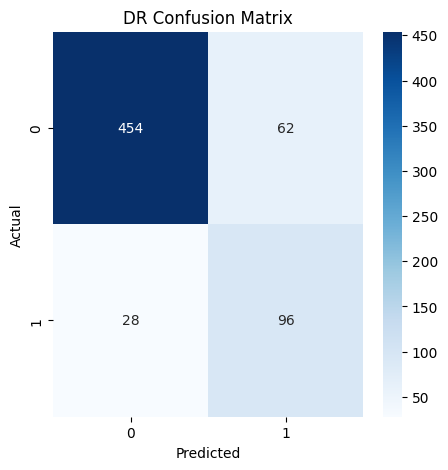

In [36]:
# ==========================================================
# CONFUSION MATRIX FOR DR
# ==========================================================

from sklearn.metrics import confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_true[:,0],
    y_pred_binary[:,0]
)

plt.figure(figsize=(5,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("DR Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [37]:
# ==========================================================
# SAVE PREDICTIONS
# ==========================================================

prediction_df = pd.DataFrame(
    y_pred,
    columns=selected_diseases
)

prediction_df.to_csv(
    "EfficientNetV2_predictions.csv",
    index=False
)

print("Predictions saved!")

Predictions saved!


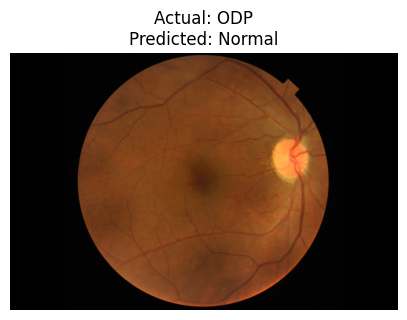

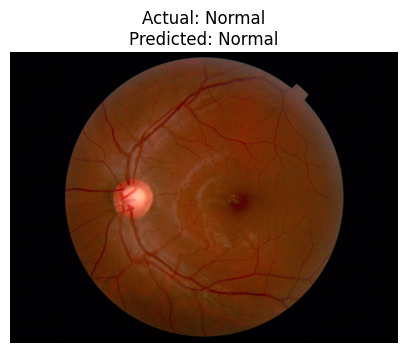

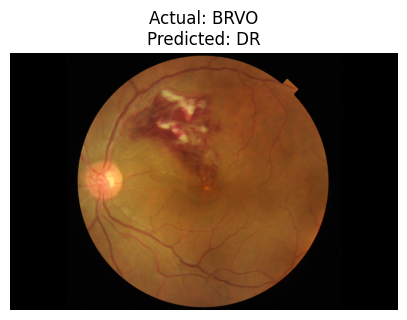

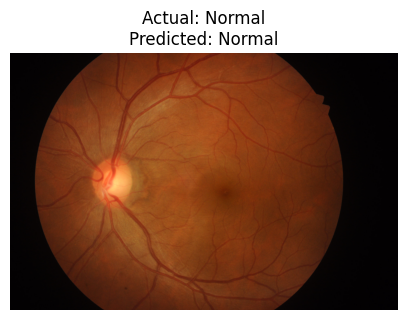

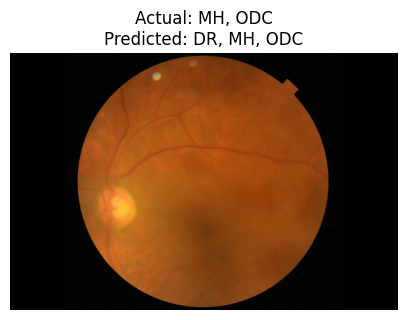

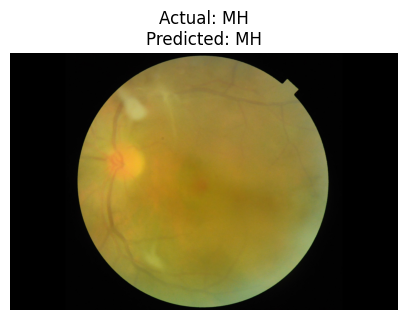

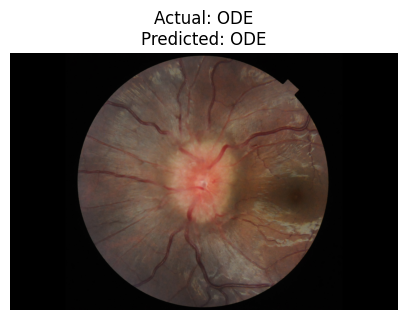

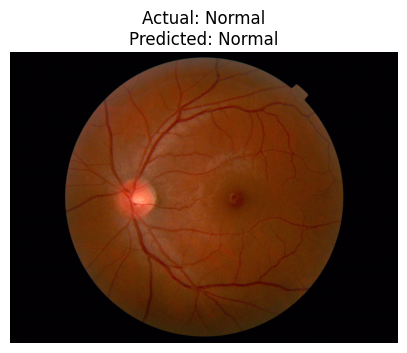

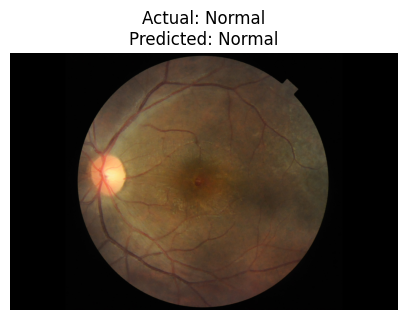

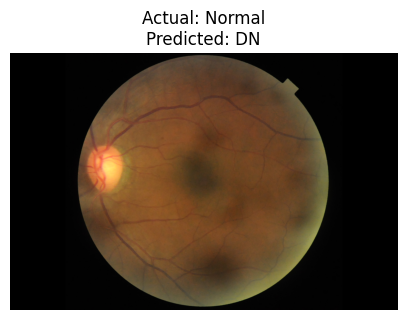

In [38]:
# ==========================================================
# SHOW SAMPLE PREDICTIONS
# ==========================================================

import random
import matplotlib.pyplot as plt

threshold = 0.5

sample_indices = random.sample(range(len(test_data)), 10)

for idx in sample_indices:

    # Read image
    img = cv2.imread(test_data.iloc[idx]["image_path"])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Actual labels
    actual = []

    for disease in selected_diseases:
        if test_data.iloc[idx][disease] == 1:
            actual.append(disease)

    if len(actual) == 0:
        actual = ["Normal"]

    # Predicted labels
    predicted = []

    for j, disease in enumerate(selected_diseases):
        if y_pred[idx][j] >= threshold:
            predicted.append(disease)

    if len(predicted) == 0:
        predicted = ["Normal"]

    # Display image
    plt.figure(figsize=(5,5))
    plt.imshow(img)
    plt.axis("off")

    plt.title(
        f"Actual: {', '.join(actual)}\n"
        f"Predicted: {', '.join(predicted)}"
    )

    plt.show()

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          0 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ normalization[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │      4,608 │ stem_activation[… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_bn  │ (None, 112, 112,  │         64 │ block1a_project_… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_ac… │ (None, 112, 112,  │          0 │ block1a_project_… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_conv │ (None, 56, 56,    │      9,216 │ block1a_project_… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_bn   │ (None, 56, 56,    │        256 │ block2a_expand_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_act… │ (None, 56, 56,    │          0 │ block2a_expand_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_co… │ (None, 56, 56,    │      2,048 │ block2a_expand_a… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_bn  │ (None, 56, 56,    │        128 │ block2a_project_… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_conv │ (None, 56, 56,    │     36,864 │ block2a_project_… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_bn   │ (None, 56, 56,    │        512 │ block2b_expand_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_act… │ (None, 56, 56,    │          0 │ block2b_expand_b

 Total params: 9,241,660 (35.25 MB)

 Trainable params: 1,495,406 (5.70 MB)

 Non-trainable params: 4,755,440 (18.14 MB)

 Optimizer params: 2,990,814 (11.41 MB)

In [40]:
model.evaluate(test_generator)

20/20 ━━━━━━━━━━━━━━━━━━━━ 230s 10s/step - accuracy: 0.9395 - auc: 0.8723 - loss: 0.2992


[0.29915446043014526, 0.9395089149475098, 0.8722658753395081]